Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

Load Dataset

In [6]:
df = pd.read_csv(
    "coretech_clients_dataset.csv"
)

df.head()

,Client_ID,Employees,Annual_Revenue,Projects_Completed,Years_With_Company,Customer_Satisfaction
0,1001,122,585822,22,2,88
1,1002,455,537879,28,7,65
2,1003,368,614685,2,14,94
3,1004,290,832038,42,10,96
4,1005,126,403531,45,3,83


Dataset Information

In [7]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Client_ID              100 non-null    int64
 1   Employees              100 non-null    int64
 2   Annual_Revenue         100 non-null    int64
 3   Projects_Completed     100 non-null    int64
 4   Years_With_Company     100 non-null    int64
 5   Customer_Satisfaction  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB
None
         Client_ID  Employees  Annual_Revenue  Projects_Completed  \
count   100.000000  100.00000      100.000000           100.00000   
mean   1050.500000  270.09000   504939.660000            24.37000   
std      29.011492  142.38879   280263.175405            14.61261   
min    1001.000000   21.00000    62666.000000             1.00000   
25%    1025.750000  147.75000   260931.000000            11.00000   
50%    1050.500000  281.00000   511916.0

Check Missing Values

In [8]:
print(df.isnull().sum())

Client_ID                0
Employees                0
Annual_Revenue           0
Projects_Completed       0
Years_With_Company       0
Customer_Satisfaction    0
dtype: int64


Feature Selection

In [9]:
features = df[
    [
        "Employees",
        "Annual_Revenue",
        "Projects_Completed",
        "Years_With_Company",
        "Customer_Satisfaction"
    ]
]

Standardization

In [10]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

Elbow Method

In [12]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(
        model.inertia_
    )

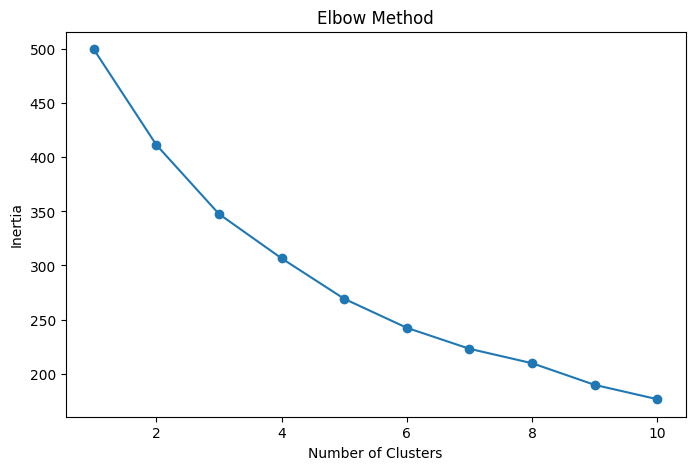

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title(
    "Elbow Method"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Inertia"
)

plt.savefig(
    "elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
from google.colab import files

files.download(
    "elbow_method.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

KMeans Clustering

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

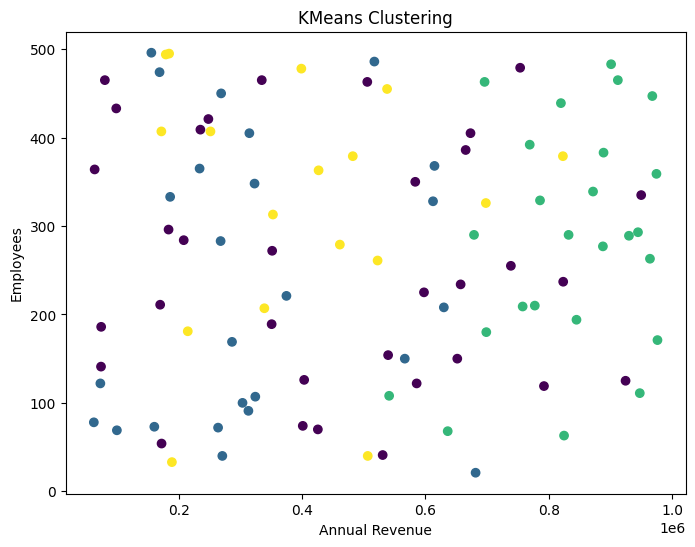

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual_Revenue"],
    df["Employees"],
    c=df["Cluster"]
)

plt.title(
    "KMeans Clustering"
)

plt.xlabel(
    "Annual Revenue"
)

plt.ylabel(
    "Employees"
)

plt.savefig(
    "kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
files.download(
    "kmeans_clusters.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Hierarchical Clustering

In [18]:
linked = linkage(
    scaled_features,
    method='ward'
)

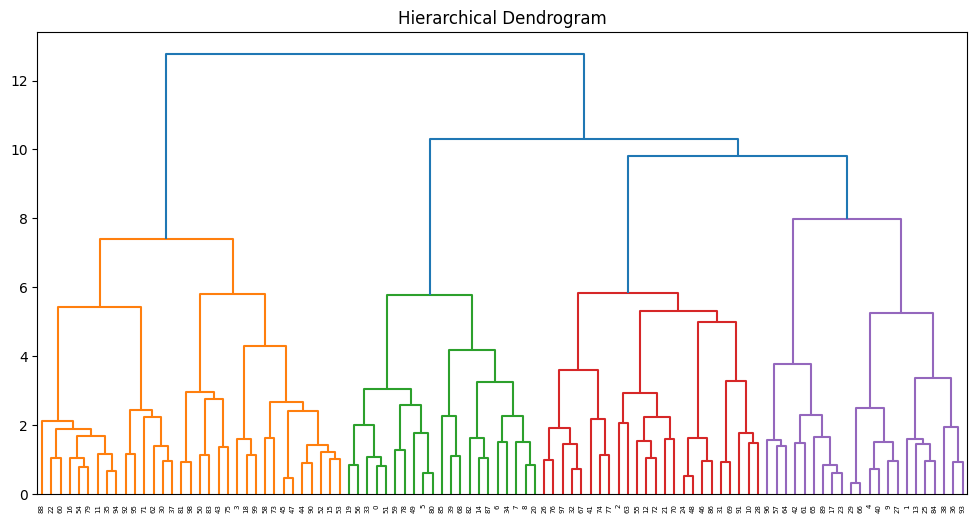

In [19]:
plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title(
    "Hierarchical Dendrogram"
)

plt.savefig(
    "hierarchical_dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
files.download(
    "hierarchical_dendrogram.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Agglomerative Clustering

In [21]:
hc = AgglomerativeClustering(
    n_clusters=4
)

df["HC_Cluster"] = hc.fit_predict(
    scaled_features
)

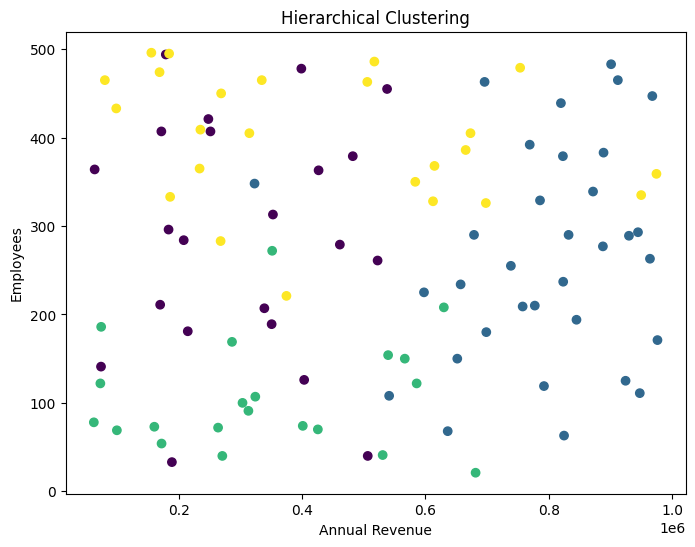

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual_Revenue"],
    df["Employees"],
    c=df["HC_Cluster"]
)

plt.title(
    "Hierarchical Clustering"
)

plt.xlabel(
    "Annual Revenue"
)

plt.ylabel(
    "Employees"
)

plt.savefig(
    "hierarchical_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
files.download(
    "hierarchical_clusters.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Business Insights

In [24]:
cluster_summary = df.groupby(
    "Cluster"
).mean(numeric_only=True)

print(cluster_summary)

           Client_ID   Employees  Annual_Revenue  Projects_Completed  \
Cluster                                                                
0        1047.060606  258.787879   450008.969697           26.030303   
1        1047.040000  234.280000   323058.120000           18.240000   
2        1058.000000  284.600000   833049.240000           35.520000   
3        1051.235294  323.352941   396528.588235           13.764706   

         Years_With_Company  Customer_Satisfaction  HC_Cluster  
Cluster                                                         
0                  3.575758              88.545455    1.606061  
1                 11.040000              86.680000    2.400000  
2                  8.680000              76.680000    1.080000  
3                  4.352941              64.470588    0.411765  


*   Cluster 0 → Small businesses with low revenue.
*   Cluster 1 → Growing companies with moderate revenue.
*   Cluster 2 → High-value enterprise clients.
*   Cluster 3 → Premium long-term clients.





# Final Dataset

In [25]:
df.to_csv(
    "clustered_clients.csv",
    index=False
)

files.download(
    "clustered_clients.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>